### Pasos para ejecutar este archivo

### instala python y demas dependencias 
- instalar python
- instalar python-venv
- instalar python-pip

### crear la carpeta del proyecto y abrirlo en vscode

### activar el entorno virtual
en Linux

 ```bash
python3 -m venv .venv
source .venv/bin/active
```

- crea el entorno virtual
- activalo

deberia aparecer algo como 

```bash
(.venv) usuario@pc:~/Documentos/AprendizajeComp$

```

### instala las dependencias para el notebook

```bash
# Actualizar pip dentro del entorno
python -m pip install --upgrade pip
# Instalar ipykernel (para que el venv pueda ser un kernel de Jupyter)
python -m pip install ipykernel

# registra el kernel con un nombre personalizable
python -m ipykernel install --user \\
  --name=aprendizajecomp \\
  --display-name="Python (AprendizajeComp)"


```

### Instalar dependencias
!pip install pandas numpy matplotlib scikit-learn joblib imbalanced-learn
Nota ejecutar solo una vez.

In [130]:
!pip install pandas numpy matplotlib scikit-learn joblib imbalanced-learn

In [131]:
import pandas as pd
import matplotlib as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier

In [132]:
wine = pd.read_csv('winequality-red.csv')
wine.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [133]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [134]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [135]:
wine.isnull().sum().sort_values(ascending=False)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [136]:
wine.quality.value_counts()


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

### Identificacion de variables X e y

El dataset tiene **1599 filas y 12 columnas**: usamos **11 variables de entrada (X)** y **1 variable objetivo (y)**, que es `quality`.

Antes de entrenar, aparecen dos problemas importantes:

1. **Demasiadas clases de calidad para este enfoque**
   La variable `quality` tiene varios niveles (3, 4, 5, 6, 7, 8). Esto vuelve la clasificacion mas compleja y dificulta que el modelo aprenda fronteras claras entre clases cercanas.

2. **Desbalance de clases**
   Al revisar `wine.quality.value_counts()`, se observa que predominan ciertas calidades (sobre todo 5 y 6), mientras que otras tienen muy pocos ejemplos. En este escenario, el modelo puede sesgarse hacia las clases mayoritarias y rendir peor en las minoritarias.

Para enfrentar ambos problemas, simplificamos el objetivo a una clasificacion binaria:

- `0`: calidad baja (`quality <= 5`)
- `1`: calidad alta (`quality >= 6`)

Ademas, aplicamos **SMOTE** en entrenamiento para equilibrar las clases y mejorar la capacidad del modelo para aprender ambas categorias.

In [137]:
# lo primero que vamos hacer es a simplificar las clases 
wine['quality_binary'] = (wine['quality'] >= 6).astype(int)
print(wine['quality_binary'].value_counts())


quality_binary
1    855
0    744
Name: count, dtype: int64


### explicacion de simplificacion

```python
wine['quality_binary'] = (wine['quality'] >= 6).astype(int)
                         │────────────────────────────────│
                         Parte que crea 0s y 1s
```

Parte 1 : ``` wine['quality'] >= 6 ```

```python
    # Si quality es:
3  → 3 >= 6?  → FALSE
4  → 4 >= 6?  → FALSE
5  → 5 >= 6?  → FALSE
6  → 6 >= 6?  → TRUE  ✓
7  → 7 >= 6?  → TRUE  ✓
8  → 8 >= 6?  → TRUE  ✓
9  → 9 >= 6?  → TRUE  ✓
```

``Resultado`` una lista de true y false
```
Original:  [3, 5, 6, 7, 8, 3, 6, ...]
Resultado: [False, False, True, True, True, False, True, ...]
```

Parte 2 ``` .astype(int) ```

```
True  → 1
False → 0
```

al final queda un arreglo de 0 y 1 0 = calidad baja 1 = calidad alta


In [138]:
from sklearn.model_selection import train_test_split

In [139]:
# random_state asegura que los resultados sean reproducibles al fijar la semilla de aleatoriedad
train, test = train_test_split(wine, test_size=0.30, random_state=42)
train.shape

(1119, 13)

In [140]:
x_train = train[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y_train = train['quality_binary']

In [141]:
x_test = test[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y_test = test['quality_binary']

In [142]:

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

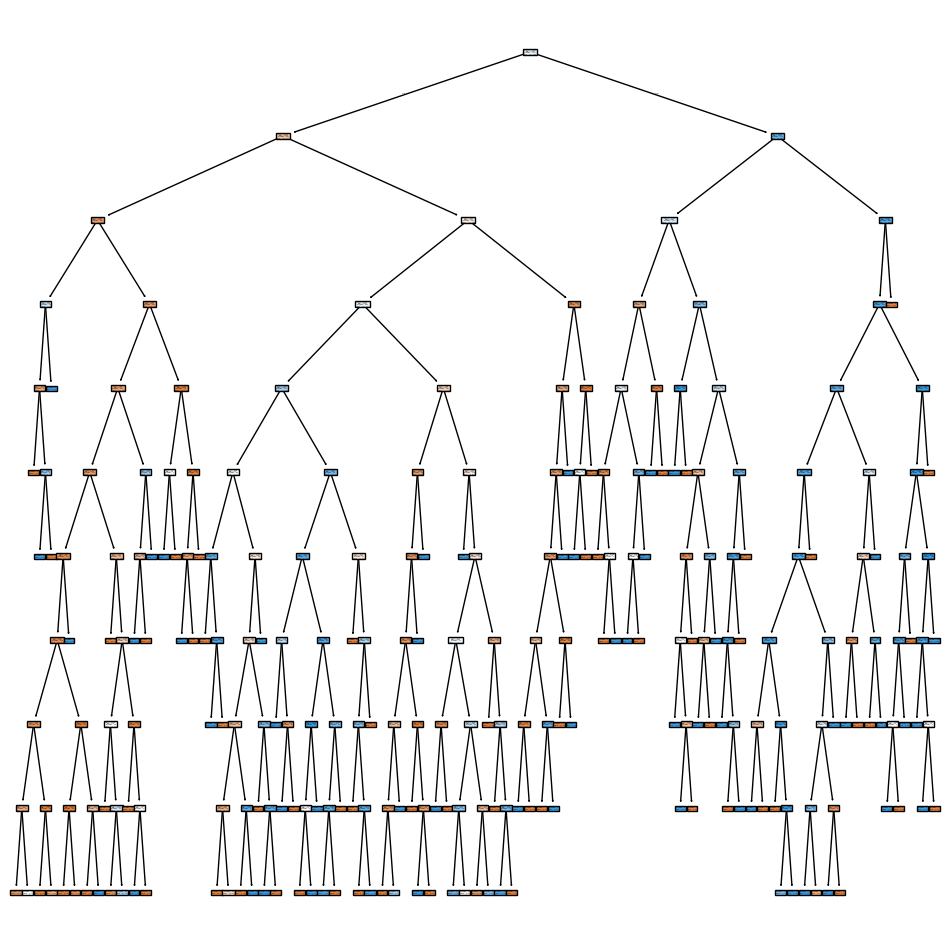

In [143]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(12, 12))
tree.plot_tree(model, filled=True)
plt.show()

In [144]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,

In [145]:
df_prediccion = pd.DataFrame(y_pred)
df_prediccion['real']=y_test.values
df_prediccion.head(10)

,0,real
0,1,1
1,0,0
2,0,1
3,1,0
4,1,1
5,0,0
6,0,0
7,0,0
8,1,0
9,1,1


In [146]:
model.score(x_test, y_test)*100

76.04166666666666

=== Metricas de calidad del modelo ===
Accuracy : 76.042
Precision: 76.389
Recall   : 82.397
F1-Score : 79.279
ROC-AUC  : 77.352

Matriz de confusion:
[[145  68]
 [ 47 220]]

Reporte de clasificacion:
                  precision    recall  f1-score   support

Baja calidad (0)       0.76      0.68      0.72       213
Alta calidad (1)       0.76      0.82      0.79       267

        accuracy                           0.76       480
       macro avg       0.76      0.75      0.75       480
    weighted avg       0.76      0.76      0.76       480



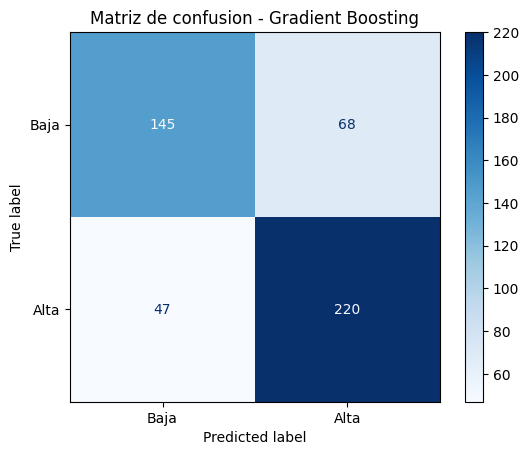

In [147]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Predicciones
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1]

# Metricas principales
accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
f1 = f1_score(y_test, y_pred)*100   
roc_auc = roc_auc_score(y_test, y_proba)*100

print("=== Metricas de calidad del modelo ===")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusion:")
print(cm)

print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["Baja calidad (0)", "Alta calidad (1)"]))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baja", "Alta"]).plot(cmap="Blues")
plt.title("Matriz de confusion - Gradient Boosting")
plt.show()

### Análisis de resultados del modelo (Árbol de Decisión)

La matriz de confusión y las métricas obtenidas corresponden a un modelo de **árbol de decisión** (`DecisionTreeClassifier`).

La matriz de confusión reporta:

- Baja calidad correctamente detectada: 145
- Alta calidad correctamente detectada: 220
- Errores en baja calidad (falsos positivos): 68
- Errores en alta calidad (falsos negativos): 47

A partir de estos valores:

- **Accuracy ≈ 76.0%**: De los 480 vinos en total, el modelo acertó en 365 clasificaciones. Es el porcentaje general de aciertos, pero no dice cómo se distribuyen los errores entre clases.

- **Precision (clase Alta) ≈ 76.4%**: De los vinos que el modelo predijo como "Alta calidad", el 76.4% realmente eran de alta calidad. Es importante cuando queremos minimizar falsos positivos (predecir alta calidad cuando no lo es).

- **Recall (clase Alta) ≈ 82.4%**: De todos los vinos que realmente son de "Alta calidad", el modelo detectó el 82.4%. Es relevante cuando queremos minimizar falsos negativos (no detectar un vino de alta calidad).

- **F1-score (clase Alta) ≈ 79.3%**: Es el balance entre precisión y recall. Un valor alto indica que el modelo es bueno tanto identificando correctamente los positivos como evitando falsos positivos.

- **ROC-AUC ≈ 77.4%**: Indica una capacidad moderada para distinguir entre vinos de alta y baja calidad.

### Interpretación

1. El árbol de decisión logra un desempeño razonable para ambas clases, con mejor detección de la clase "Alta calidad" (recall más alto).
2. La clase "Baja calidad" tiene recall más bajo (0.68), lo que indica que algunos vinos de baja calidad se confunden como alta calidad.
3. El F1-score balanceado sugiere que el modelo no sacrifica demasiado la precisión por el recall.
4. El ROC-AUC en torno a 0.77 muestra que el modelo discrimina, aunque todavía hay margen de mejora.
5. Para mejorar, se podría ajustar la profundidad del árbol o probar técnicas de balanceo/regularización.

### Exportar un unico pipeline para 

Se crea el modelo (`modelo_vino_pipeline_v1.pkl`) Para usarlo desde app.


In [148]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

pipeline.fit(x_train, y_train)

joblib.dump(pipeline, "modelo_vino_pipeline_v1.pkl")

print("Listo: modelo_vino_pipeline_v1.pkl generado.")
print(f"Accuracy test: {pipeline.score(x_test, y_test) * 100:.2f}%")

Listo: modelo_vino_pipeline_v1.pkl generado.
Accuracy test: 70.83%
